In [1]:
import pandas as pd
from plotnine import *
import numpy as np
from vpop_calibration.api import *

%load_ext autoreload
%autoreload 2

## Loading Reference Data

In [2]:
df = pd.read_csv("../../../examples/benchmarking/Mavoglurant/Mavoglurant_Dataset.csv")


obs_df = (
    df.loc[df["EVID"] == 0]
    .rename(columns={"ID": "id", "TIME": "time", "DV": "value", "DOSE": "dose"})[
        ["id", "time", "value", "dose", "WT"]
    ]
    .astype({"value": "float"})
)
obs_df["time"] = obs_df["time"].apply(lambda t: t * 60 * 60)
obs_df["value"] = obs_df["value"].apply(lambda t: np.log(t))
obs_df["output_name"] = "logC15"
obs_df["protocol_arm"] = "identity"
display(df.head())
display(obs_df.head())

,ID,CMT,EVID,MDV,DV,AMT,TIME,DOSE,OCC,RATE,AGE,SEX,WT,HT,occ
0,793,Venous_Blood,1,1,0.0,25.0,0.000,25.0,1,75,42,1,94.3,1.769997,1
1,793,C15,0,0,491.0,0.0,0.200,25.0,1,0,42,1,94.3,1.769997,1
2,793,C15,0,0,605.0,0.0,0.250,25.0,1,0,42,1,94.3,1.769997,1
3,793,C15,0,0,556.0,0.0,0.367,25.0,1,0,42,1,94.3,1.769997,1
4,793,C15,0,0,310.0,0.0,0.533,25.0,1,0,42,1,94.3,1.769997,1


,id,time,value,dose,WT,output_name,protocol_arm
1,793,720.0,6.196444,25.0,94.3,logC15,identity
2,793,900.0,6.405228,25.0,94.3,logC15,identity
3,793,1321.2,6.320768,25.0,94.3,logC15,identity
4,793,1918.8,5.736572,25.0,94.3,logC15,identity
5,793,2520.0,5.468060,25.0,94.3,logC15,identity


## Reference model

In [3]:
model = SimworkModelBinding(
    path_to_model="../../../examples/benchmarking/Mavoglurant/cm.json",
    path_to_solving_options="../../../examples/benchmarking/Mavoglurant/sv.json",
    inputs=["KbBR", "CLint", "KbMU", "KbAD", "KbBO", "KbRB", "dose", "WT"],
    outputs=["logC15"],
)
print(model.inputs)

struct_model = StructuralSimwork(model=model)

['KbBR', 'CLint', 'KbMU', 'KbAD', 'KbBO', 'KbRB', 'dose', 'WT']


## Optimize model using SAEM

In [6]:
prior_pdu = {
    "model_intrinsic": {
        "KbBR": {"prior": np.exp(1.1)},
        "KbMU": {"prior": np.exp(0.3)},
        "KbBO": {"prior": np.exp(0.03)},
        "KbAD": {"prior": np.exp(2)},
        "KbRB": {"prior": np.exp(0.3)},
    },
    "pdu": {
        "CLint": {"prior": np.exp(7.6), "prior_omega": 1},
    },
    "pdk": {"WT", "dose"},
    "error_model": {
        "logC15": {"error_type": "additive", "sigma": 0.5},
    },
}

config = Config(
    saem=SaemConfigDict(
        nb_iter_burnin=30,
        nb_iter_learning=200,
        nb_iter_smoothing=100,
        fixed_effects_nb_iter=1,
        plot_frames=5,
    ),
    nlme=NlmeConfigDict(nb_chains=1),
)

nlme_model = NlmeModel(
    df=obs_df, input_params=prior_pdu, structural_model=struct_model, config=config
)

  0%|          | 0/330 [00:00<?, ?it/s]

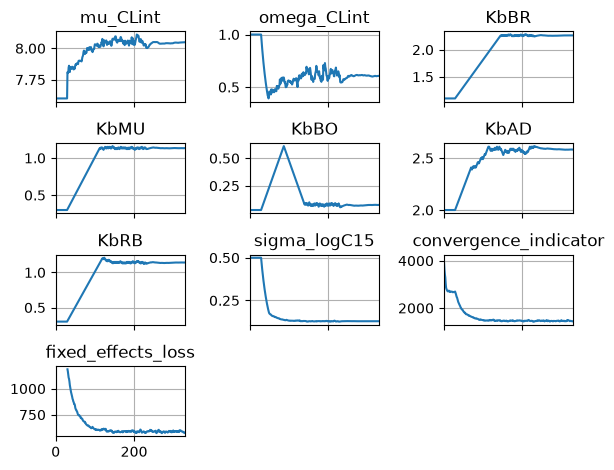

In [7]:
nlme_model.optimizer.run()

Sampling already started, adding 400 new samples.


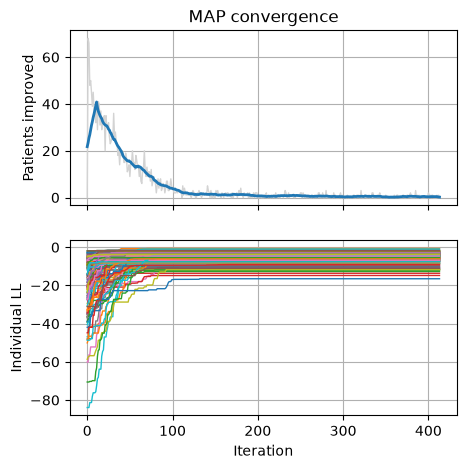

  0%|          | 0/400 [00:00<?, ?it/s]

In [10]:
nlme_model.diagnostics.sample_conditional_distribution(nb_samples=400)

In [11]:
nlme_model.diagnostics.sampler.map_parameters_df.to_csv("Simwork_map.csv", index=False)

In [ ]:
nlme_model.diagnostics.compute_vpc(quantiles=[0.05, 0.5, 0.95])
vpc_py = nlme_model.diagnostics.vpc
vpc_py["model"] = "Simwork"
vpc_py.to_csv("Simwork_VPC.csv", index=False)
print(vpc_py.head(12))